# Lankah 1: import libary dan persiapan data (Tren Linear)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error

# Pengaturan visualisasi
plt.style.use('fivethirtyeight')

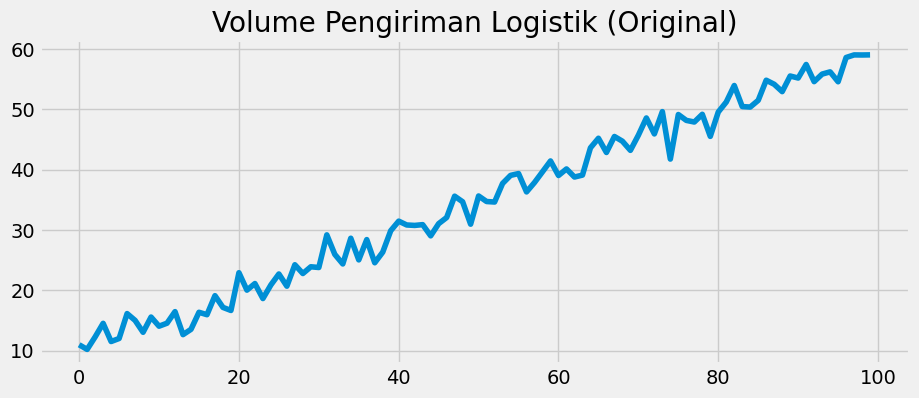

In [2]:
# 1. Membuat data sintetis
np.random.seed(42)
t = np.arange(100)

# Data memiliki tren (0.5*t) dan variansi acak
y = 10 + 0.5 * t + np.random.normal(0, 2, 100)
df = pd.DataFrame({'Volume': y})

# Visualisasi Data Awal
df['Volume'].plot(figsize=(10, 4), title='Volume Pengiriman Logistik (Original)')
plt.show()

# Langah 2: Uji Stasioneritas & Differencing (Orde d)

In [3]:
# Uji ADF pada data asli
result = adfuller(df['Volume'])
print(f'p-value asli: {result[1]}') # Jika > 0.05, lakukan diff

# First-order Differencing
df_diff = df['Volume'].diff().dropna()
result_diff = adfuller(df_diff)
print(f'p-value setelah diff: {result_diff[1]}') # d = 1 jika p < 0.05

p-value asli: 0.9691007111144091
p-value setelah diff: 9.019393985742185e-06


# langkah 3: Identifikasi Orde p dan q (ACF & PACF)

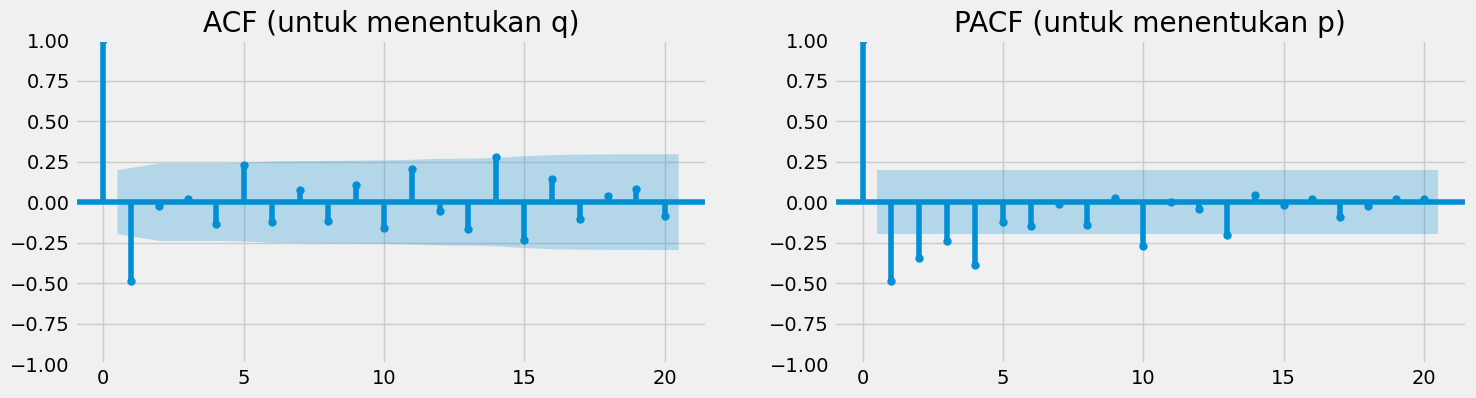

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_diff, ax=ax1, title='ACF (untuk menentukan q)')
plot_pacf(df_diff, ax=ax2, title='PACF (untuk menentukan p)')
plt.show()

# Langkah 4: Fitting MOdel ARIMA

In [5]:
# Membagi data train (80) dan test (20)
train = df['Volume'][:80]
test = df['Volume'][80:]

# Membangun Model ARIMA(1, 1, 1)
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# Menampilkan Ringkasan Model
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 Volume   No. Observations:                   80
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -180.429
Date:                Wed, 03 Jun 2026   AIC                            366.857
Time:                        03:56:57   BIC                            373.966
Sample:                             0   HQIC                           369.705
                                 - 80                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1903      0.240     -0.793      0.428      -0.661       0.280
ma.L1         -0.3826      0.243     -1.572      0.116      -0.860       0.095
sigma2         5.6164      0.942      5.964      0.0

# Langkah 5: Diagnostik Residu

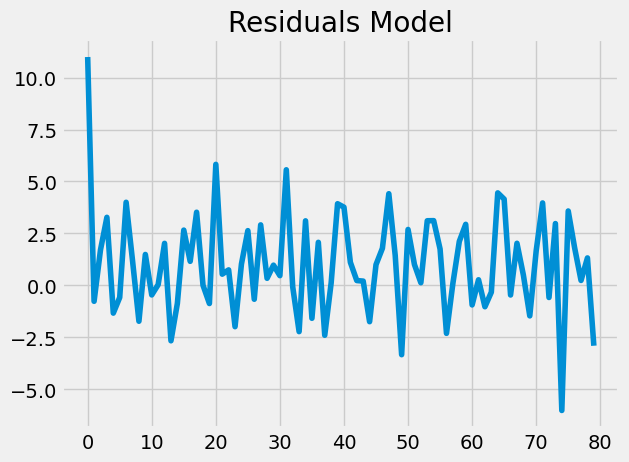

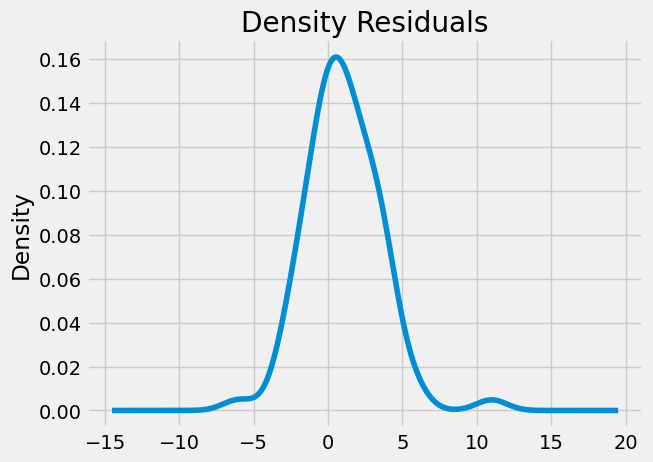

In [6]:
# Plot residu
residuals = model_fit.resid
residuals.plot(title="Residuals Model")
plt.show()

# Plot histogram residu (harus mendekati distribusi normal)
residuals.plot(kind='kde', title='Density Residuals')
plt.show()

# Langkah 6: Peramalan (Forecasting)

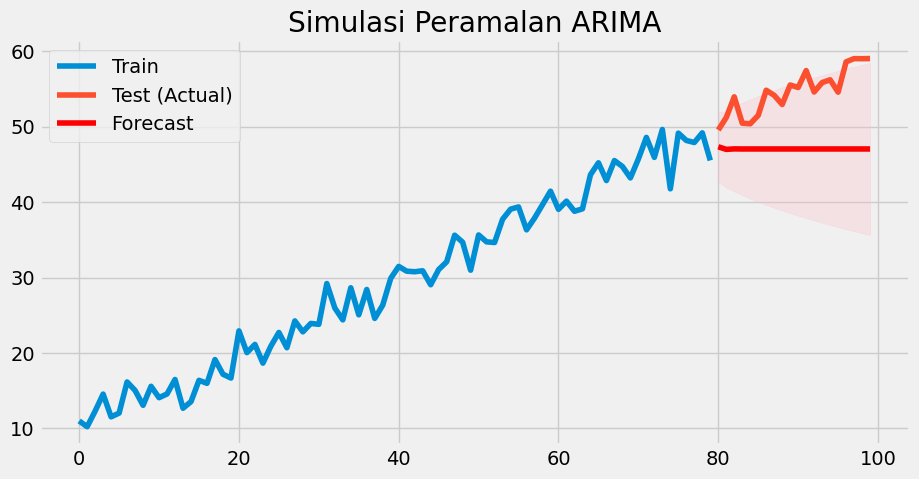

MAPE (Mean Absolute Percentage Error): 13.72%


In [7]:
# Melakukan ramalan untuk 20 langkah ke depan
forecast_obj = model_fit.get_forecast(steps=20)
y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# Visualisasi Hasil Ramalan
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test (Actual)')
plt.plot(test.index, y_pred, label='Forecast', color='red')
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.legend()
plt.title("Simulasi Peramalan ARIMA")
plt.show()

# Hitung MAPE
mape = mean_absolute_percentage_error(test, y_pred)
print(f"MAPE (Mean Absolute Percentage Error): {mape*100:.2f}%")